
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [69]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [70]:
# from src.data.metadata import filter_graphs_by_metadata

# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4p5-more"],
# )

# print(f"After timepoint filter: {len(graphs)} organoids.")

In [71]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [72]:
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)


In [73]:
from src.data.metadata import strip_graph_metadata

graphs = strip_graph_metadata(graphs, inplace=False)

In [74]:
from src.data.splits import standardize_graph_targets, train_val_split_graphs

# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

Split -> train: 705 | val: 176


In [75]:
# from src.data.permutation import permute_graph_targets_within_organoid, permute_graph_features_within_organoid

# g_train = permute_graph_targets_within_organoid(g_train, inplace=False)
# g_val = permute_graph_targets_within_organoid(g_val, inplace=False)

# g_train = permute_graph_features_within_organoid(g_train, inplace=False)
# g_val = permute_graph_features_within_organoid(g_val, inplace=False)


In [76]:
center, scale = standardize_graph_targets(g_train, g_val, robust=True)

In [ ]:
from src.models.gnn import PureSAGECurvature


num_layers = 3
n_markers = int(g_train[0].x.size(1))

model = PureSAGECurvature(
    n_markers=n_markers,
    hidden_dim=64,
    num_layers=num_layers,
    dropout=0.1,      
    residual=True,
    norm='batch'      
)

In [78]:
# from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP
# from src.data.ring_features import attach_precomputed_ring_features

# num_layers = 3
# n_markers = int(g_train[0].x.size(1))

# g_train = attach_precomputed_ring_features(g_train, k_hops=num_layers, inplace=False)
# g_val = attach_precomputed_ring_features(g_val, k_hops=num_layers, inplace=False)


# # model = RingFractionMLP(
# #     n_markers=n_markers,
# #     hidden_dim=64,
# #     k_hops=num_layers,
# #     dropout=0.1,      
# #     norm='batch'      
# # )


# model = PooledKHopMLP(
#     n_markers=n_markers,
#     hidden_dim=64,
#     k_hops=num_layers,
#     dropout=0.1,      
#     norm='batch'      
# )

In [79]:
from src.training.loop import TrainConfig, train


cfg = TrainConfig(
    loss_name="gaussian",
    lr=1e-3,
    batch_size=128,
    max_epochs=200,
    patience=30,
    num_workers=4,
)

model, metrics, history = train(model, g_train, g_val, cfg)

epoch 001 | train loss 1.0583 mae 1.0191 | val loss 0.8966 mae 0.9671
epoch 002 | train loss 0.9074 mae 0.9892 | val loss 0.8146 mae 0.9486
epoch 003 | train loss 0.8886 mae 0.9951 | val loss 0.8103 mae 0.9407
epoch 004 | train loss 0.8585 mae 0.9839 | val loss 0.8071 mae 0.9355
epoch 005 | train loss 0.8514 mae 0.9674 | val loss 0.7766 mae 0.9323
epoch 006 | train loss 0.8389 mae 0.9680 | val loss 0.7533 mae 0.9347
epoch 007 | train loss 0.8321 mae 0.9706 | val loss 0.7471 mae 0.9382
epoch 008 | train loss 0.8282 mae 0.9702 | val loss 0.7440 mae 0.9357
epoch 009 | train loss 0.8266 mae 0.9645 | val loss 0.7440 mae 0.9336
epoch 010 | train loss 0.8190 mae 0.9565 | val loss 0.7424 mae 0.9338
epoch 011 | train loss 0.8229 mae 0.9600 | val loss 0.7392 mae 0.9366
epoch 012 | train loss 0.8172 mae 0.9665 | val loss 0.7465 mae 0.9453
epoch 013 | train loss 0.8119 mae 0.9622 | val loss 0.7410 mae 0.9330
epoch 014 | train loss 0.8101 mae 0.9577 | val loss 0.7378 mae 0.9299
epoch 015 | train lo

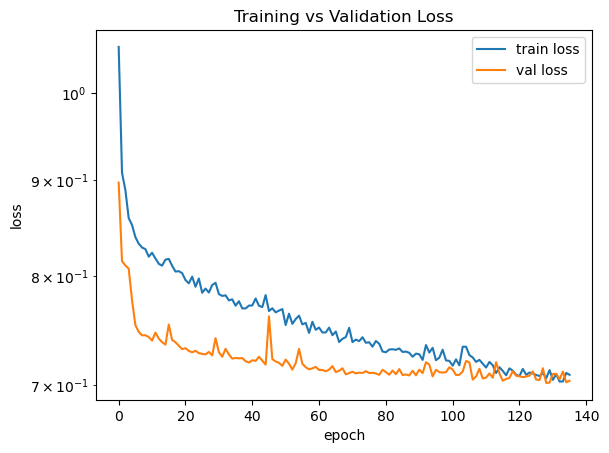

In [80]:
plt.figure()
plt.plot(history.get("train_loss", []), label="train loss")
plt.plot(history.get("val_loss", []), label="val loss")
plt.yscale('log')
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training vs Validation Loss")
plt.legend(); plt.show()


In [81]:
from src.inference.predict import predict_targets
from src.analysis.prediction_analysis import rescale_distribution_outputs
from src.analysis.marker_stats import compute_markerwise_residuals

device = cfg.device if 'cfg' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')

# === Inference on VALIDATION ===
y, mu, log_var, X = predict_targets(g_val, model, device=device, return_log_var=True)

# transform back (if you trained on standardized targets)
y, mu, log_var = rescale_distribution_outputs(y, mu, log_var=log_var, center=center, scale=scale)

# Residuals per marker (positives only) using mean prediction
residuals_model, residuals_base, n_pos, mu_pos = compute_markerwise_residuals(y, mu, X)


In [82]:
from src.data.metadata import load_marker_names_from_dir

# Helper: pick top markers by positives for display
marker_names = load_marker_names_from_dir(data_dir)
order_by_n = np.argsort(-n_pos)
marker_idx_show = order_by_n[:min(12, (X.shape[1] if X.ndim == 2 else 12))]
marker_names_sel = [marker_names[m] if m < len(marker_names) else f"m{m}" for m in marker_idx_show]

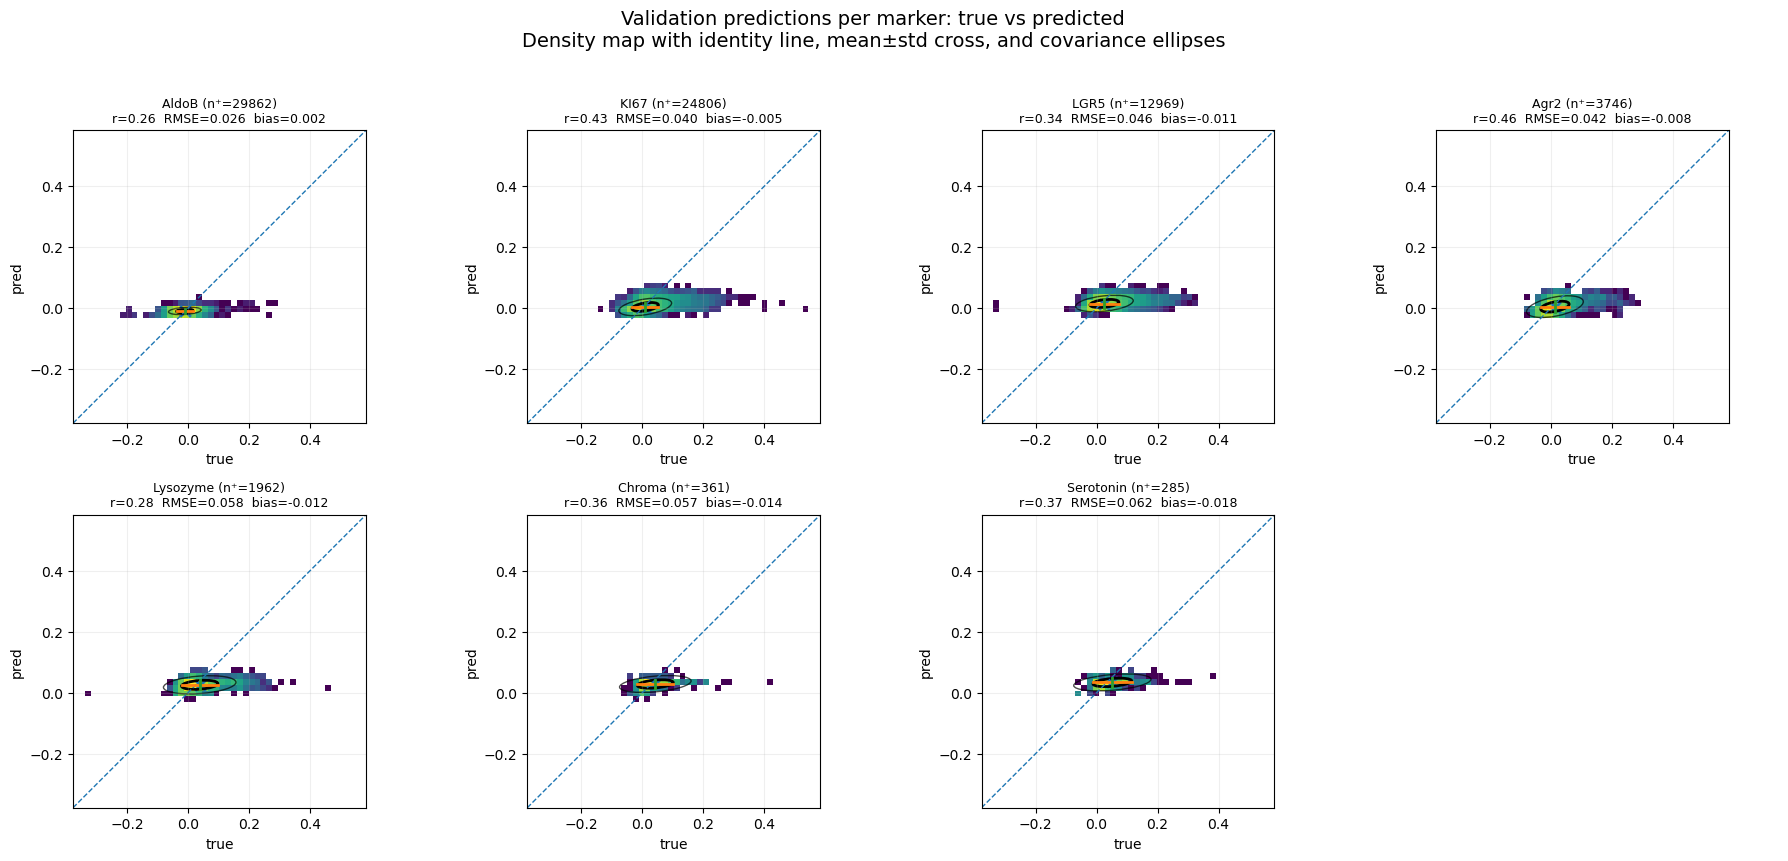

In [83]:
from matplotlib.patches import Ellipse
from matplotlib.colors import LogNorm

def add_cov_ellipse(ax, x, y, n_std=1.0, **kwargs):
    """
    Draw covariance ellipse for points (x, y).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.size < 2 or y.size < 2:
        return

    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return

    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0.0)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2.0 * n_std * np.sqrt(vals)

    ell = Ellipse(
        xy=(x.mean(), y.mean()),
        width=width,
        height=height,
        angle=theta,
        fill=False,
        **kwargs,
    )
    ax.add_patch(ell)


# === Layout ===
cols = 4
rows = int(np.ceil(len(marker_idx_show) / cols)) if len(marker_idx_show) else 1
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.6, rows * 4.2), squeeze=False)
axes = axes.ravel()

# === Global axis range across shown markers ===
all_true = []
all_pred = []
for m in marker_idx_show:
    mask = X[:, m] > 0.5
    yt = np.asarray(y[mask], dtype=float)
    yp = np.asarray(mu[mask], dtype=float)
    good = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[good], yp[good]
    if yt.size > 0:
        all_true.append(yt)
        all_pred.append(yp)

if len(all_true) == 0:
    raise RuntimeError("No valid points found for the selected markers.")

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

global_lo = min(all_true.min(), all_pred.min())
global_hi = max(all_true.max(), all_pred.max())
pad = 0.05 * (global_hi - global_lo + 1e-12)
global_lo -= pad
global_hi += pad

# Use a square 2D histogram with log-count coloring.
# This is much clearer than raw scatter when counts vary from ~200 to >14000.
nbins = 50
hist_range = [[global_lo, global_hi], [global_lo, global_hi]]

for k, m in enumerate(marker_idx_show):
    ax = axes[k]

    mask = X[:, m] > 0.5
    yt = np.asarray(y[mask], dtype=float)
    yp = np.asarray(mu[mask], dtype=float)

    good = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[good], yp[good]

    if yt.size == 0:
        ax.axis("off")
        continue

    n = yt.size
    mean_t, mean_p = yt.mean(), yp.mean()
    std_t, std_p = yt.std(ddof=0), yp.std(ddof=0)
    rmse = np.sqrt(np.mean((yp - yt) ** 2))
    bias = np.mean(yp - yt)
    r = np.corrcoef(yt, yp)[0, 1] if n > 1 else np.nan

    # Main density plot
    hb = ax.hist2d(
        yt,
        yp,
        bins=nbins,
        range=hist_range,
        norm=LogNorm(),
        cmin=1,
    )

    # Identity line
    ax.plot([global_lo, global_hi], [global_lo, global_hi], linestyle="--", linewidth=1)

    # Mean point
    ax.scatter([mean_t], [mean_p], s=60, marker="x", linewidths=2)

    # Std cross
    ax.plot([mean_t - std_t, mean_t + std_t], [mean_p, mean_p], linewidth=2)
    ax.plot([mean_t, mean_t], [mean_p - std_p, mean_p + std_p], linewidth=2)

    # 1 std and 2 std covariance ellipses
    add_cov_ellipse(ax, yt, yp, n_std=1.0, linewidth=2)
    add_cov_ellipse(ax, yt, yp, n_std=2.0, linewidth=1, alpha=0.7)

    ax.set_xlim(global_lo, global_hi)
    ax.set_ylim(global_lo, global_hi)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

    ax.set_title(
        f"{marker_names_sel[k]} (n⁺={n_pos[m]})\n"
        f"r={r:.2f}  RMSE={rmse:.3f}  bias={bias:.3f}",
        fontsize=9,
    )
    ax.set_xlabel("true")
    ax.set_ylabel("pred")

for k in range(len(marker_idx_show), len(axes)):
    axes[k].axis("off")

# One shared colorbar
# cbar = fig.colorbar(hb[3], ax=axes[:len(marker_idx_show)], shrink=0.9, pad=0.02)
# cbar.set_label("count per bin (log scale)")

fig.suptitle(
    "Validation predictions per marker: true vs predicted\n"
    "Density map with identity line, mean±std cross, and covariance ellipses",
    y=1.02,
    fontsize=14,
)

plt.tight_layout()
plt.show()

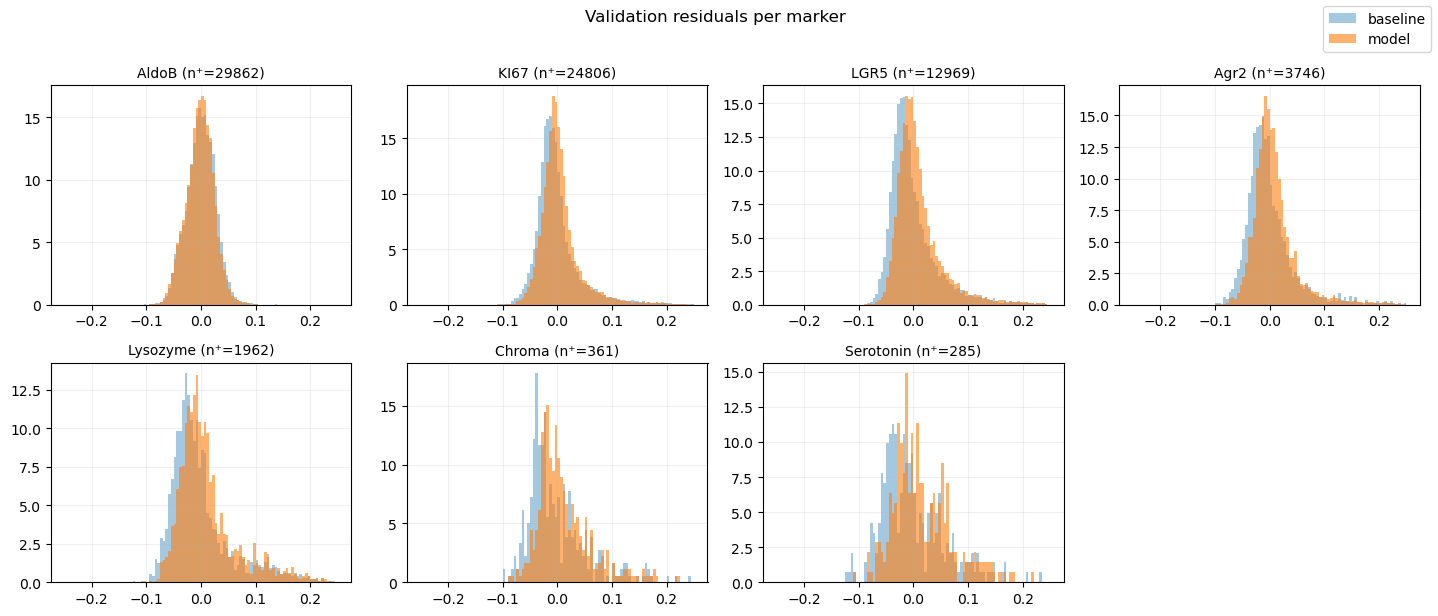

In [84]:

# === Histograms of residuals per marker (model vs baseline) ===
cols = 4
rows = int(np.ceil(len(marker_idx_show)/cols)) if len(marker_idx_show) else 1

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.6, rows*3.0), squeeze=False)

axes = axes.ravel()
edges = np.linspace(-0.25, 0.25, 101)  # symmetric bins

for k, m in enumerate(marker_idx_show):
    ax = axes[k]
    rb = residuals_base[m]; rm = residuals_model[m]
    if rb.size == 0:
        ax.axis('off'); continue
    ax.hist(rb, bins=edges, density=True, alpha=0.4, label="baseline")
    ax.hist(rm, bins=edges, density=True, alpha=0.6, label="model")
    ax.set_title(f"{marker_names_sel[k]} (n⁺={n_pos[m]})", fontsize=10)
    ax.grid(True, alpha=0.2)

for k in range(len(marker_idx_show), len(axes)):
    axes[k].axis('off')
if len(marker_idx_show):
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
fig.suptitle("Validation residuals per marker", y=1.02)
plt.tight_layout(); plt.show()


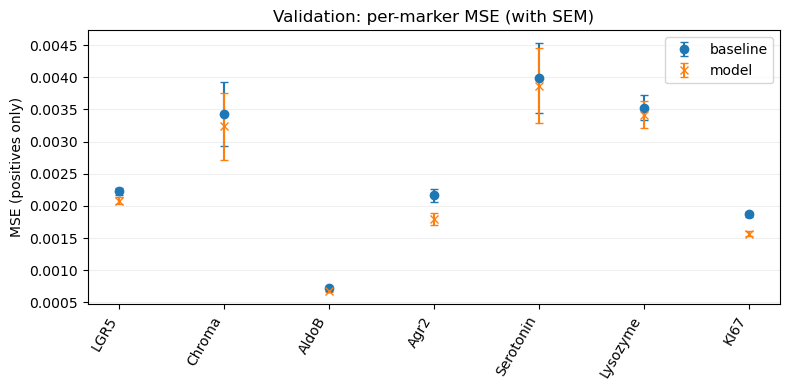

In [85]:
# MSE and SEM (SEM over squared residuals)
mse_model = np.array([np.mean(r**2) for r in residuals_model])
mse_base  = np.array([np.mean(r**2) for r in residuals_base])
sem_model = np.array([np.std((r**2), ddof=1)/np.sqrt(r.size) for r in residuals_model])
sem_base  = np.array([np.std((r**2), ddof=1)/np.sqrt(r.size) for r in residuals_base])

x = np.arange(len(marker_names))

plt.figure(figsize=(max(8, 0.5*len(marker_names)), 4))
plt.errorbar(x, mse_base,  yerr=sem_base,  fmt='o', capsize=3, label="baseline")
plt.errorbar(x, mse_model, yerr=sem_model, fmt='x', capsize=3, label="model")
plt.xticks(x, marker_names, rotation=60, ha='right')
plt.ylabel("MSE (positives only)")
plt.title("Validation: per-marker MSE (with SEM)")
plt.grid(True, axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


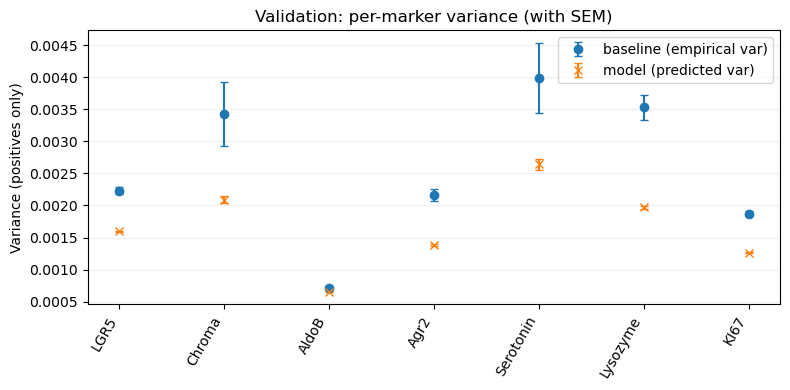

In [86]:
Xb = (X > 0.5)  # boolean positives

# Model: mean predicted variance per marker among positives
var_model = np.array([np.mean(np.exp(log_var[Xb[:, m]])) for m in range(X.shape[1])])
sem_var_model = np.array([np.std(np.exp(log_var[Xb[:, m]]), ddof=1) / np.sqrt(np.sum(Xb[:, m]))
                          for m in range(X.shape[1])])

# Baseline: empirical residual variance (same as your MSE baseline)
# (positives only, already computed as mse_base + sem_base in your code)
var_base = mse_base
sem_var_base = sem_base

x = np.arange(len(marker_names))

plt.figure(figsize=(max(8, 0.5*len(marker_names)), 4))
plt.errorbar(x, var_base,     yerr=sem_var_base,     fmt='o', capsize=3, label="baseline (empirical var)")
plt.errorbar(x, var_model,    yerr=sem_var_model,    fmt='x', capsize=3, label="model (predicted var)")
plt.xticks(x, marker_names, rotation=60, ha='right')
plt.ylabel("Variance (positives only)")
plt.title("Validation: per-marker variance (with SEM)")
plt.grid(True, axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## Neighborhood Perturbation Analysis

### What this analysis does

We quantify how **local cell-type composition** influences predicted organoid surface curvature by performing **controlled perturbations** on ego-subgraphs centered at individual cells.

For each ego-subgraph and each hop distance $h = 1,\dots,k$:

1. We identify all cells exactly $h$ hops away from the center cell.
2. For each marker $X$, we perturb that marker on the hop-$h$ neighborhood
   (typically by setting all $X^+$ cells in that ring to $X = 0$).
3. We re-run the trained GNN and record how the **center cell’s predicted curvature**
   changes relative to the unperturbed prediction.

The analysis is repeated across many ego-subgraphs and aggregated:
- **Globally**, averaging over all center cells.
- **Conditioned on center cell type**, i.e. separately for center cells positive for marker $Y$.

All reported effects are normalized by the number of perturbed marker-positive cells,
so values should be interpreted as **effects per perturbed positive** rather than per subgraph.

---

### What is measured

For each perturbation we measure changes in the predicted Gaussian output at the center cell:

- $\Delta \mu = \mu_{\text{perturbed}} - \mu_{\text{original}}$
- $\Delta \log \sigma^2 = \log \sigma^2_{\text{perturbed}} - \log \sigma^2_{\text{original}}$

---

### Interpretation of $\Delta \mu$

- **Positive $\Delta \mu$**  
  Removing marker $X$ from the neighborhood causes the model to predict **higher curvature**
  at the center cell.  
  → The presence of marker $X$ normally *suppresses* curvature.

- **Negative $\Delta \mu$**  
  Removing marker $X$ causes the model to predict **lower curvature**.  
  → The presence of marker $X$ normally *promotes* curvature.

Thus, $\Delta \mu$ captures the **directional influence** of neighborhood cell types on
local tissue bending.

---

### Interpretation of $\Delta \log \sigma^2$

- **Positive $\Delta \log \sigma^2$**  
  Removing marker $X$ makes the model **more uncertain** about the center cell’s curvature.  
  → Marker $X$ provides stabilizing or disambiguating information.

- **Negative $\Delta \log \sigma^2$**  
  Removing marker $X$ makes the model **more confident** in its curvature prediction.  
  → Marker $X$ contributes to variability or ambiguity in curvature outcomes.

Thus, $\Delta \log \sigma^2$ reflects how neighborhood composition affects
**predictive uncertainty**, not just the mean shape.

---

### What the figures show

Each figure consists of one heatmap per hop distance:

- **Columns (X-axis)**: perturbed neighborhood markers $X$
- **Rows (Y-axis)**: center cell markers $Y$
- **Color**: average $\Delta \mu$ or $\Delta \log \sigma^2$ per perturbed positive

Each heatmap answers the question:

> *“Given that the center cell is $Y^+$, how does removing marker $X$ from its
> hop-$h$ neighborhood affect the predicted curvature (or uncertainty) at the center?”*

These maps reveal:
- cell-type–specific interaction ranges,
- which neighborhood signals actively drive curvature,
- and which signals primarily stabilize or destabilize morphological outcomes.


In [87]:
from src.data.subgraphs import build_ego_subgraphs_for_dataset 

num_hops   = num_layers

val_subgraphs  = build_ego_subgraphs_for_dataset(
    g_val,
    num_hops=num_hops,
    max_centers_per_graph=None,  # e.g. 80 random centers per organoid
    seed=0,
)

In [88]:
from src.data.subgraph_sampling import sample_subgraphs_coverage, print_sampling_summary

sampled_val_subgraphs, sample_info = sample_subgraphs_coverage(
    val_subgraphs,
    marker_names=marker_names,
    k_hops=num_layers,          # or the k_hops you will perturb over
    max_subgraphs=2000,          # your budget
    min_center_count=40,
    min_pair_count=25,
    seed=0,
)

print_sampling_summary(sample_info, marker_names)

Selected 2000 / 74011 subgraphs

Center coverage:
LGR5          covered= 424  target=  40  available=12969  OK
Chroma        covered=  71  target=  40  available= 361  OK
AldoB         covered= 812  target=  40  available=29862  OK
Agr2          covered= 145  target=  40  available=3746  OK
Serotonin     covered=  75  target=  40  available= 285  OK
Lysozyme      covered= 103  target=  40  available=1962  OK
KI67          covered= 697  target=  40  available=24806  OK

Unsatisfied center markers: []
Unsatisfied pair features: 1


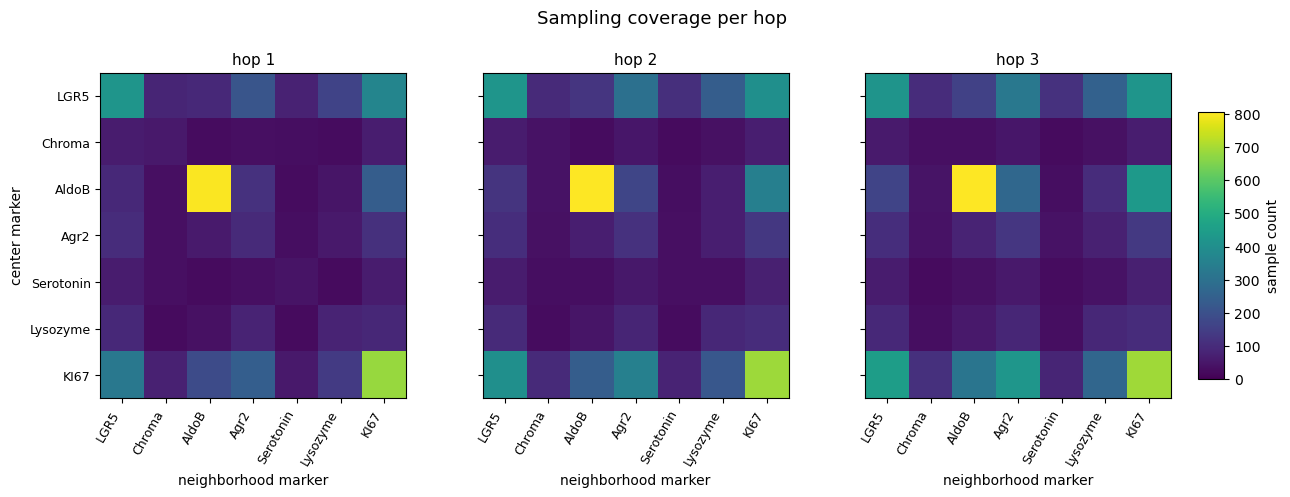

In [89]:
pair_cov = sample_info["pair_covered"]   # (H, M, M)

H, M, _ = pair_cov.shape

# shared colorscale
vmin = 0
vmax = np.max(pair_cov)

# ---- figure ----
fig, axes = plt.subplots(
    1, H,
    figsize=(H * (0.38 * M + 1.8), 0.38 * M + 2.2),
)

if H == 1:
    axes = [axes]

for hi, ax in enumerate(axes):

    im = ax.imshow(
        pair_cov[hi],
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        aspect="auto",
    )

    ax.set_title(f"hop {hi+1}", fontsize=11)

    ax.set_xticks(range(M))
    ax.set_xticklabels(marker_names, rotation=60, ha="right", fontsize=9)

    ax.set_yticks(range(M))
    if hi == 0:
        ax.set_yticklabels(marker_names, fontsize=9)
        ax.set_ylabel("center marker")
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("neighborhood marker")

# ---- reserve space for colorbar ----
fig.subplots_adjust(
    left=0.08,
    right=0.88,   # <---- leaves white margin on right
    bottom=0.18,
    top=0.85,
    wspace=0.25,
)

# ---- colorbar axis ----
cax = fig.add_axes([0.90, 0.22, 0.02, 0.55])   # [left, bottom, width, height]

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("sample count")

fig.suptitle("Sampling coverage per hop", fontsize=13)

plt.show()

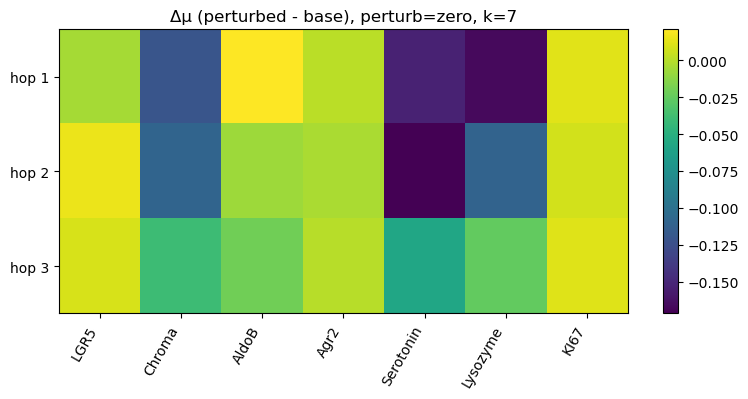

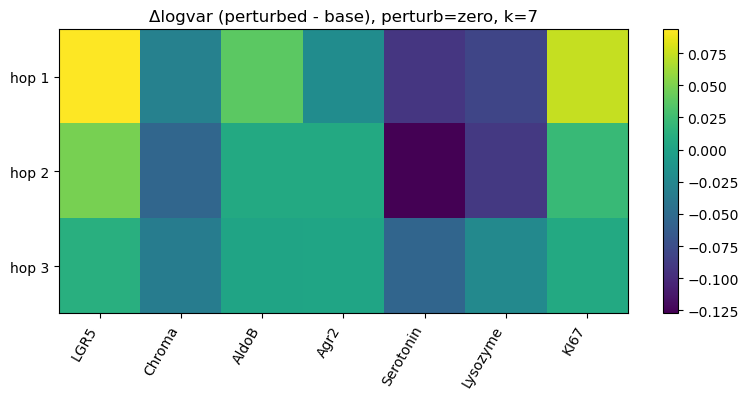

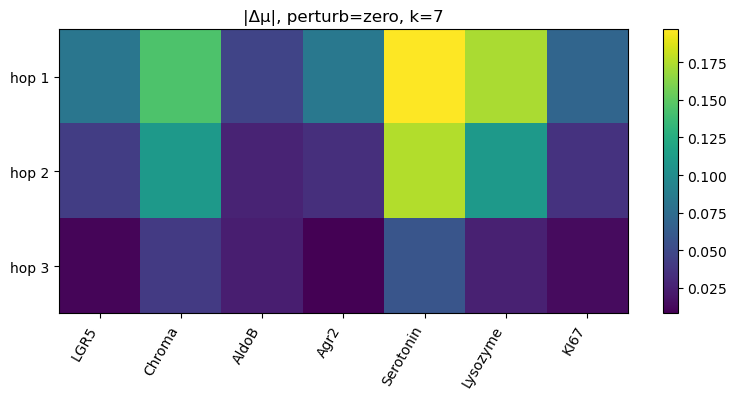

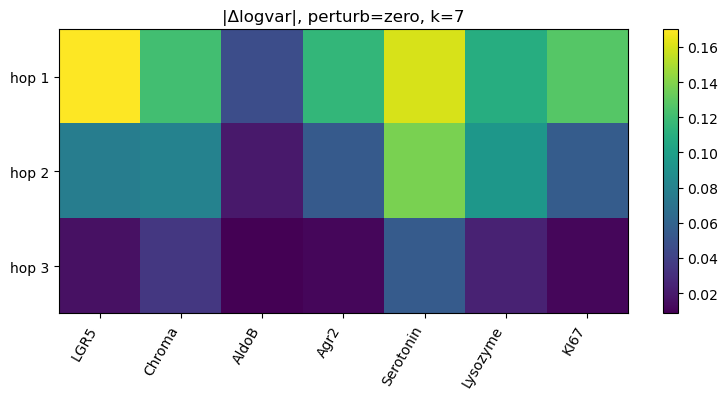

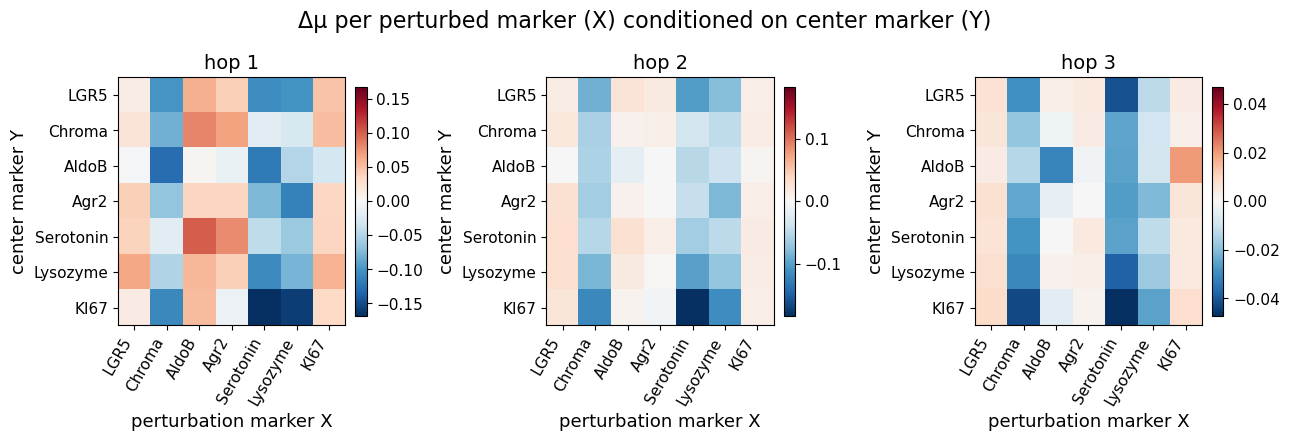

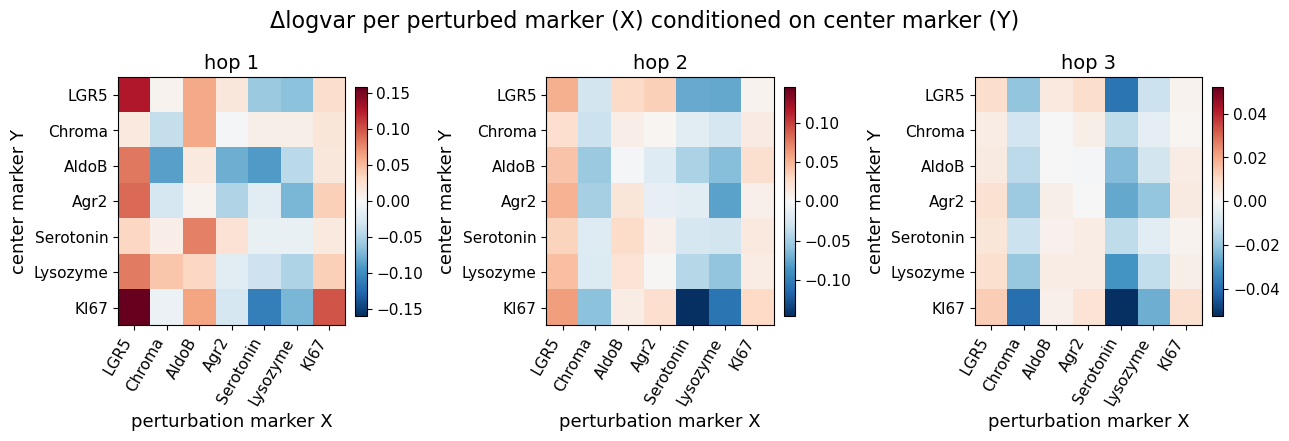

In [90]:
from src.analysis.perturbation import compute_perturbation_influence_maps
from src.plotting.influence_maps import plot_influence_heatmap, plot_influence_center_resolved

res = compute_perturbation_influence_maps(
    subgraphs=sampled_val_subgraphs,
    model=model,
    marker_names=marker_names,
    k_hops=num_hops,
    mode="single",         
    max_subgraphs=None,      # start small (e.g. 100-500), then scale up
    batch_size=128,
)

# Mean shifts (directional effect)
plot_influence_heatmap(res["delta_mu_total"], res["hops"], res["marker_names"],
                       title=f"Δμ (perturbed - base), perturb=zero, k={k}")

plot_influence_heatmap(res["delta_lv_total"], res["hops"], res["marker_names"],
                       title=f"Δlogvar (perturbed - base), perturb=zero, k={k}")

# Magnitude-only (how strong the dependence is)
plot_influence_heatmap(res["delta_mu_abs_total"], res["hops"], res["marker_names"],
                       title=f"|Δμ|, perturb=zero, k={k}")

plot_influence_heatmap(res["delta_lv_abs_total"], res["hops"], res["marker_names"],
                       title=f"|Δlogvar|, perturb=zero, k={k}")


plot_influence_center_resolved(
    res["delta_mu_cmarker"], res["hops"], res["marker_names"],
    title="Δμ per perturbed marker (X) conditioned on center marker (Y)",
    sort_center=False, center_zero=True, cmap='RdBu_r'
)

plot_influence_center_resolved(
    res["delta_lv_cmarker"], res["hops"], res["marker_names"],
    title="Δlogvar per perturbed marker (X) conditioned on center marker (Y)",
    sort_center=False, center_zero=True, cmap='RdBu_r'
)


In [91]:
from src.analysis.composition import compute_neighborhood_composition, fit_sparse_neighborhood_improvement_models, fit_sparse_neighborhood_uncertainty_models

# Example choices:
mode = "presence"   # or "presence"
hops = 3            # up to k

X_center, X_neigh = compute_neighborhood_composition(
    g_val,
    hops=hops,
    mode=mode,
    include_center=False,
)

influence = fit_sparse_neighborhood_improvement_models(
    y_true=y,
    y_pred_mu=mu,
    X_center=X_center,
    X_neigh=X_neigh,
    marker_names=marker_names,
    alpha=1e-3,              # sparsity knob (try 1e-4, 1e-3, 1e-2)
    use_squared_error=True,  # improvement in squared error
)

# Example: print top neighbor markers for each center marker
for A, name in enumerate(marker_names):
    top = influence[A]["top"]
    if top:
        print(f"\nCenter {name}+: top neighborhood influences on improvement")
        for nb_name, coef in top:
            print(f"  {nb_name:>12s}  coef={coef:+.4f}")

In [92]:
unc_inf = fit_sparse_neighborhood_uncertainty_models(
    y_true=y,
    X_center=X_center,
    X_neigh=X_neigh,
    pred_var=np.exp(log_var),
    marker_names=marker_names,
    alpha=1e-3,
)

for A, name in enumerate(marker_names):
    top = unc_inf[A]["top"]
    if top:
        print(f"\nCenter {name}+: top neighborhood influences on uncertainty reduction")
        for nb_name, coef in top:
            print(f"  {nb_name:>12s}  coef={coef:+.4f}")
